# Check the Chemical Network Output of DiskMINT models

In [1]:
# %matplotlib widget
%matplotlib inline
%reload_ext autoreload
%autoreload 2

import datetime, os, sys, copy

import numpy as np
import pandas as pd

from astropy.io import fits
import astropy.units as u
import astropy.constants as C

import tqdm

# for interpolate
from scipy import interpolate
from scipy.optimize import curve_fit

import matplotlib
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import cmasher as cmr

style = [
    # 'seaborn-ticks',
    {
        'figure.dpi': 300,
        'figure.figsize': (3.5, 3.5 / 1.618),
        'font.size': 12,  # 12
        'image.cmap': 'inferno',
        'font.family': 'serif',
        'font.serif': ['Times', 'Times New Roman'] + plt.rcParams['font.serif'],
        'xtick.top': True,
        'xtick.direction': 'out',
        'ytick.right': True,
        'ytick.direction': 'out',
        'mathtext.fontset': 'cm'
        }]

plt.style.use(style)

import diskmint.model as model
import diskmint.disk_density as dd
import diskmint.constants as const
import diskmint.modelgrid as modelgrid
import diskmint.dustopac as dustopac
import diskmint.execute as exe

## Import the utils for this work

In [2]:
# navigate to the work direcotry

work_dir = os.getcwd()
working_dir = work_dir

os.chdir(work_dir)
print(os.getcwd())
sys.path.append(os.getcwd())

utils_dir = os.path.join(work_dir, "..", "..", "example_utils")
sys.path.append(utils_dir)
import diskmint_utils as utils

/Users/dingshandeng/github/0-Project_Disk_Models/DiskMINT/examples/example_diskmint_models/example_diskmint_model_0p5ms_star


## Set up the directories for the model

In [3]:
output_dir = os.path.join(work_dir, 'output')
model_dirs = sorted([d for d in os.listdir(output_dir)
                     if os.path.isdir(os.path.join(output_dir, d))])

print(model_dirs)

['diskmint_similar_to_HH30_example_20260223_t0_mdust1p0e-04ms_gtd100_pla3p50_amax0p10']


## Select the model

In [4]:
chem_model_list = [
    model for model in model_dirs
    ]

name_infigure_list = [
    "similar to HH30", 
]

# chemi save name
if len(chem_model_list) >= 1:
    # dir for reading CO init grid
    data_dir_init     = os.path.join(output_dir, chem_model_list[0]) + '/'
    # dir for reading CO end grid
    data_dir_chemical  = data_dir_init
    chem_model0 = chem_model_list[0]
    name_infigure_model0 = name_infigure_list[0]

if len(chem_model_list) >= 2:
    data_dir_init1    = os.path.join(output_dir, chem_model_list[1]) + '/'
    data_dir_chemical1 = data_dir_init1
    chem_model1 = chem_model_list[1]
    name_infigure_model1 = name_infigure_list[1]

# if len(chem_model_list) >= 3:
#     chem_model2 = chem_model_list[2]
#     name_infigure_model2 = name_infigure_list[2]

In [5]:
""" model 0 """
if len(chem_model_list) >= 1:
    df_COinit_comb_model0 = utils.read_model(chem_model0, data_dir_init, data_dir_chemical, have_CO2 = 'reducedRGH22')

    (rr_2D_model0, zrr_2D_model0), (rr_grid_model0, zrr_grid_model0), (tauv_star_2D_model0, tauv_zup_2D_model0),\
    nH_1_init_2D_model0, Tgas_1_init_2D_model0, nH2_1_end_2D_model0, nC18O_1_end_2D_model0 \
    = utils.name_modelpara(df_COinit_comb_model0, nr_LIME = 215, nz_LIME = 200)

""" model 1 """
if len(chem_model_list) >= 2:
    df_COinit_comb_model1 = utils.read_model(chem_model1, data_dir_init1, data_dir_chemical1, have_CO2 = 'reducedRGH22')

    (rr_2D_model1, zrr_2D_model1), (rr_grid_model1, zrr_grid_model1), (tauv_star_2D_model1, tauv_zup_2D_model1),\
    nH_1_init_2D_model1, Tgas_1_init_2D_model1, nH2_1_end_2D_model1, nC18O_1_end_2D_model1 \
    = utils.name_modelpara(df_COinit_comb_model1, nr_LIME = 215, nz_LIME = 200) # nr_LIME = 260, nz_LIME = 200)

""" model 2 """
if len(chem_model_list) >= 3:
    df_COinit_comb_model2 = utils.read_model(chem_model2, data_dir_init1, data_dir_chemical1, have_CO2 = 'reducedRGH22')

    (rr_2D_model2, zrr_2D_model2), (rr_grid_model2, zrr_grid_model2), (tauv_star_2D_model2, tauv_zup_2D_model2),\
    nH_1_init_2D_model2, Tgas_1_init_2D_model2, nH2_1_end_2D_model2, nC18O_1_end_2D_model2 \
    = utils.name_modelpara(df_COinit_comb_model2, nr_LIME = 215, nz_LIME = 200)

# """ model 3 """
# df_COinit_comb_model3 = utils.read_model(chem_model3, data_dir_init1, data_dir_chemical1, have_CO2 = 'reducedRGH22')

# (rr_2D_model3, zrr_2D_model3), (rr_grid_model3, zrr_grid_model3), (tauv_star_2D_model3, tauv_zup_2D_model3),\
# nH_1_init_2D_model3, Tgas_1_init_2D_model3, nH2_1_end_2D_model3, nC18O_1_end_2D_model3 \
# = utils.name_modelpara(df_COinit_comb_model3, nr_LIME = 200, nz_LIME = 200) # nr_LIME = 260, nz_LIME = 200)

reading in the init file /Users/dingshandeng/github/0-Project_Disk_Models/DiskMINT/examples/example_diskmint_models/example_diskmint_model_0p5ms_star/output/diskmint_similar_to_HH30_example_20260223_t0_mdust1p0e-04ms_gtd100_pla3p50_amax0p10/COinitgrid-diskmint_similar_to_HH30_example_20260223_t0_mdust1p0e-04ms_gtd100_pla3p50_amax0p10-cyl.dat
reading in the chem file /Users/dingshandeng/github/0-Project_Disk_Models/DiskMINT/examples/example_diskmint_models/example_diskmint_model_0p5ms_star/output/diskmint_similar_to_HH30_example_20260223_t0_mdust1p0e-04ms_gtd100_pla3p50_amax0p10/COendgrid-reducedRGH22-diskmint_similar_to_HH30_example_20260223_t0_mdust1p0e-04ms_gtd100_pla3p50_amax0p10-cyl.chem


In [6]:
if len(chem_model_list) >= 1:
    print(chem_model0)
    nr_t = 215
    nz_t = 200
    whole_data_t = utils.compute_emittinglayer(df_COinit_comb_model0, dv_set = 0.0, nr = nr_t, nz = nz_t)
    r_au_2D_model0, z_au_2D_model0, \
    dlum21_2D_model0, dlum32_2D_model0, tauup_CO_2D_model0 \
    = utils.read_emittinglayer(wholedata=whole_data_t, nr = nr_t, nz = nz_t)

if len(chem_model_list) >= 2:
    print(chem_model1)
    nr_t = 215
    nz_t = 200
    whole_data_t = utils.compute_emittinglayer(df_COinit_comb_model1, dv_set = 0.0, nr = nr_t, nz = nz_t)
    r_au_2D_model1, z_au_2D_model1, \
    dlum21_2D_model1, dlum32_2D_model1, tauup_CO_2D_model1 \
    = utils.read_emittinglayer(wholedata=whole_data_t, nr = nr_t, nz = nz_t)
    
if len(chem_model_list) >= 3:
    print(chem_model2)
    nr_t = 215
    nz_t = 200
    whole_data_t = utils.compute_emittinglayer(df_COinit_comb_model2, dv_set = 0.0, nr = nr_t, nz = nz_t)
    r_au_2D_model2, z_au_2D_model2, \
    dlum21_2D_model2, dlum32_2D_model2, tauup_CO_2D_model2 \
    = utils.read_emittinglayer(wholedata=whole_data_t, nr = nr_t, nz = nz_t)

# print(chem_model3)
# utils.compute_emittinglayer(df_COinit_comb_model3, dv_set = 0.0, nr = 200, nz = 200)
# r_au_2D_model3, z_au_2D_model3, \
# dlum21_2D_model3, dlum32_2D_model3, tauup_CO_2D_model3 \
# = utils.read_emittinglayer(nr = 200, nz = 200)

diskmint_similar_to_HH30_example_20260223_t0_mdust1p0e-04ms_gtd100_pla3p50_amax0p10
C18O 2-1 4.175e-10 Lsolar
C18O 3-2 2.198e-09 Lsolar


## Plot

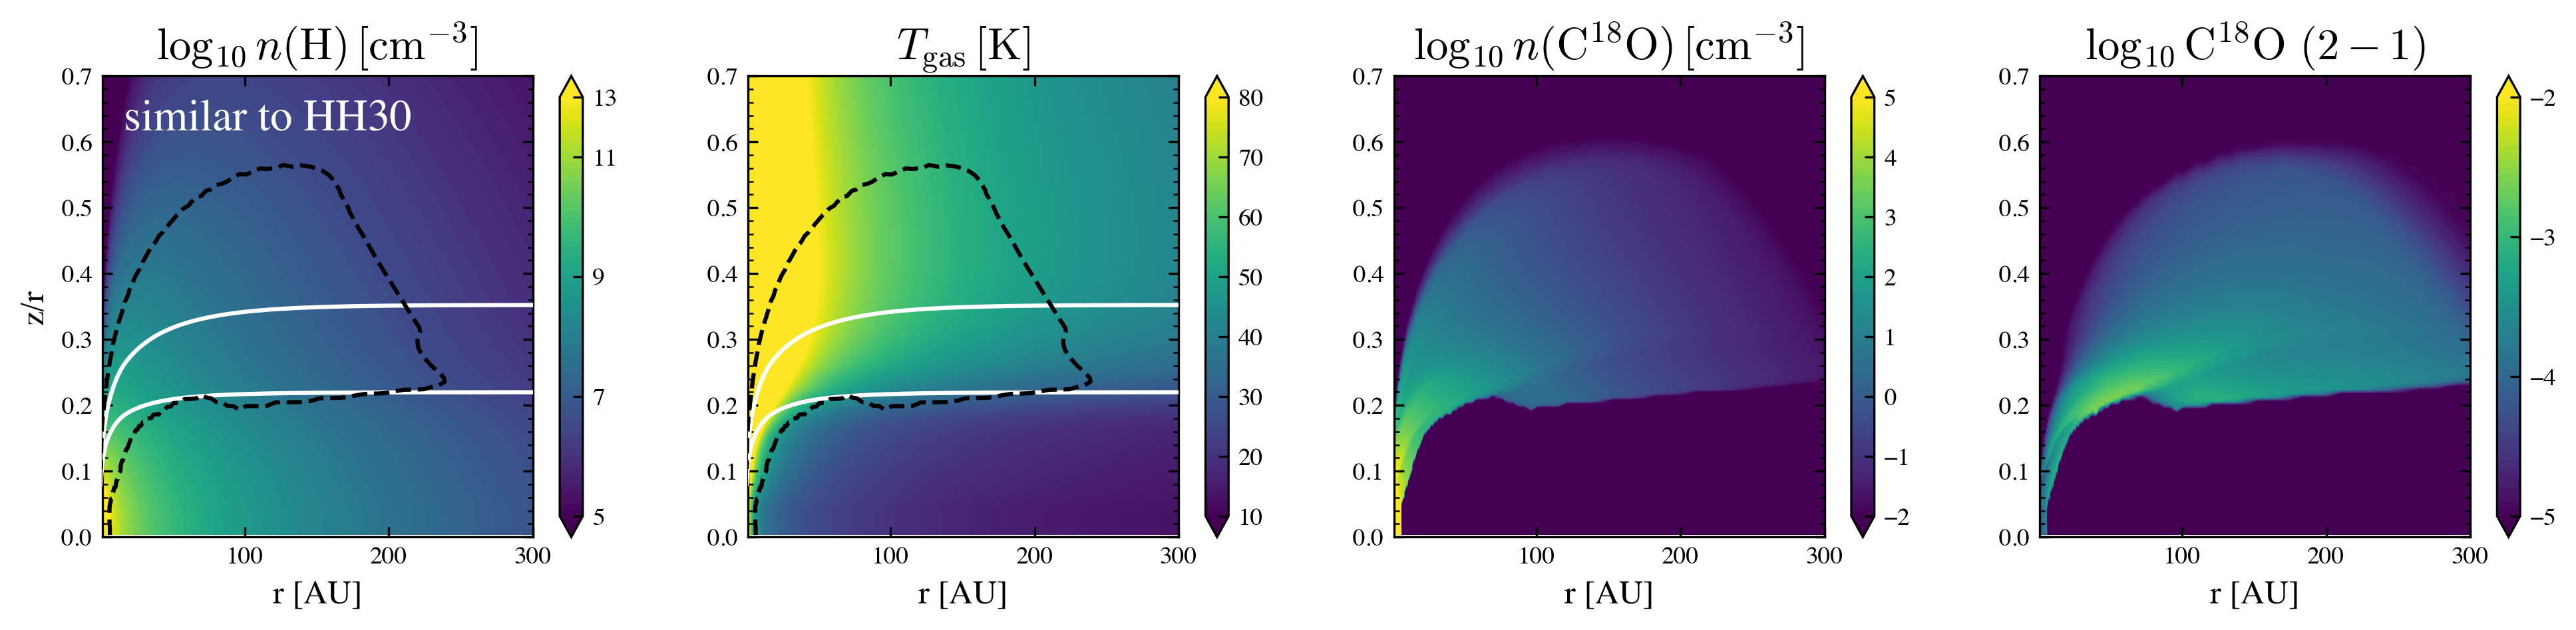

In [ ]:
x_scale = 'linear' # 'log' # 'linear'
cmap_selected_t = 'jet' # 'rainbow' # 'viridis'

nr_gridcol = 4 # nr of columns
nr_gridrow = int(len(chem_model_list)) # nr of rows # nr of models

# lim_nH = np.arange(4, 12.1, 0.1)
# ticksrange_nH = np.arange(4, 14, 2)

# # Tgas in linear scale
# lim_Tgas = np.arange(10, 80.1, 0.1)
# ticksrange_Tgas = np.arange(10, 90, 10)

# # Tgas in log scale
# # lim_Tgas = np.arange(0, 3.1, 0.1)
# # ticksrange_Tgas = np.arange(0, 3.5, 0.5)

# lim_nC18O = np.arange(-1, 4.05, 0.05)
# ticksrange_nC18O = np.arange(-1, 5, 1)

ticksrange_lum21_t = np.arange(-5.0, -2+1, 1)
# ticksrange_lum32 = np.arange(-4.0, -0.5, 0.5)

# limstep = 0.05
# lim_lum21 = np.arange(np.min(ticksrange_lum21), np.max(ticksrange_lum21) + limstep, limstep)
# lim_lum32 = np.arange(np.min(ticksrange_lum32), np.max(ticksrange_lum32) + limstep, limstep)

# titlelocator_prev = [5, 0.95]
titlelocator = [0.05, 0.95]

limymin, limymax = 0, 0.7
limxmin, limxmax = 1.0, 300.0

# textsize = 16

fig, ax = plt.subplots(nr_gridrow, nr_gridcol, figsize=(4*nr_gridcol, 3*nr_gridrow), dpi=300)
# ax[row, col]

lim_t = [5, 12]
lim_nH_t = np.arange(lim_t[0], lim_t[1]+0.1, 0.1) # np.arange(8, 12.1, 0.1) # 
ticksrange_nH_t = np.arange(lim_t[0], lim_t[1]+2, 2) # np.arange(8, 14, 2) # 

lim_t = [-2, 5]
lim_nC18O_t = np.arange(lim_t[0], lim_t[1]+0.05, 0.05)
ticksrange_nC18O_t = np.arange(lim_t[0], lim_t[1]+1, 1)

for i_model in range(len(chem_model_list)):
    if i_model == 0:
        if len(ax.shape) > 1:
            axes_t = ax[0, :]
        else:
            axes_t = ax
        utils.plot_density_emitting_layer(fig, axes_t, rr_grid_model0, zrr_grid_model0, nH_1_init_2D_model0, Tgas_1_init_2D_model0, tauv_star_2D_model0, nC18O_1_end_2D_model0,dlum21_2D_model0,bool_set_title=True,name_infigure=name_infigure_model0, lim_nH = lim_nH_t, ticksrange_nH = ticksrange_nH_t, ticksrange_nC18O=ticksrange_nC18O_t, lim_nC18O=lim_nC18O_t, ticksrange_lum21 = ticksrange_lum21_t) # , cmap_selected=cmap_selected_t)
    if i_model == 1:
        utils.plot_density_emitting_layer(fig, ax[1, :], rr_grid_model1, zrr_grid_model1, nH_1_init_2D_model1, Tgas_1_init_2D_model1, tauv_star_2D_model1, nC18O_1_end_2D_model1,dlum21_2D_model1,bool_set_title=False,name_infigure=name_infigure_model1, lim_nH = lim_nH_t, ticksrange_nH = ticksrange_nH_t, ticksrange_nC18O=ticksrange_nC18O_t, lim_nC18O=lim_nC18O_t, ticksrange_lum21 = ticksrange_lum21_t)
    if i_model == 2:
        utils.plot_density_emitting_layer(fig, ax[2, :], rr_grid_model2, zrr_grid_model2, nH_1_init_2D_model2, Tgas_1_init_2D_model2, tauv_star_2D_model2, nC18O_1_end_2D_model2,dlum21_2D_model2,bool_set_title=False,name_infigure=name_infigure_model2, lim_nH = lim_nH_t, ticksrange_nH = ticksrange_nH_t, ticksrange_nC18O=ticksrange_nC18O_t, lim_nC18O=lim_nC18O_t, ticksrange_lum21 = ticksrange_lum21_t)
    if i_model == 3:
        utils.plot_density_emitting_layer(fig, ax[3, :], rr_grid_model3, zrr_grid_model3, nH_1_init_2D_model3, Tgas_1_init_2D_model3, tauv_star_2D_model3, nC18O_1_end_2D_model3,dlum21_2D_model3,bool_set_title=False,name_infigure=name_infigure_model3, lim_nH = lim_nH_t, ticksrange_nH = ticksrange_nH_t) # , cmap_selected=cmap_selected_t, temp_scale='log', lim_Tgas_log = np.arange(0.5, 3.8, 0.1), ticksrange_Tgas_log = np.arange(0.5, 3.7+0.4, 0.4))

# for i_ax in [0, 1, 2, 3]:
# for i_ax in [0, 1]:
for i_ax in range(nr_gridrow):
    i_ax = int(i_ax)
    #
    # plot the emitting layer
    #
    # ax[i_ax, 2].plot(rr_A2018, hrr_A2018, linestyle = '--', color = 'brown', zorder = 100)
    # ax[i_ax, 3].plot(rr_A2018, hrr_A2018, linestyle = '--', color = 'brown', zorder = 100)
    if len(ax.shape) > 1:
        for j_ax in [0, 1, 2, 3]:
            ax[i_ax, j_ax].set_xscale(x_scale)
            ax[i_ax, j_ax].set_xlim(limxmin, limxmax)
            ax[i_ax, j_ax].set_ylim(limymin, limymax)
    else:
        for j_ax in [0, 1, 2, 3]:
            ax[j_ax].set_xscale(x_scale)
            ax[j_ax].set_xlim(limxmin, limxmax)
            ax[j_ax].set_ylim(limymin, limymax)

if len(ax.shape) > 1:
    for j_ax in [0, 1, 2, 3]:
        ax[-1, j_ax].set_xlabel(r'r [AU]',fontsize=12)
else:
    for j_ax in [0, 1, 2, 3]:
        ax[j_ax].set_xlabel(r'r [AU]',fontsize=12)
    
# fig.suptitle('xsacle: %s'%(x_scale))

################
# Save the Fig #
################

# plt.savefig('Fig-density-DSHARP-n.png', dpi = 300, bbox_inches='tight', pad_inches=0.1)

plt.show()